## Лаборатона робота №2

**Виконали:**
- Сачек Владислава КА-31
- Богданова Олександра КА-32
- Плахтій Злата КА-32

**Хід роботи:**

1. Завантажити простий набiр зображень згiдно з варiантом.
2. Виконати пiдготовку даних для навчання - за необхiдностi, залежно вiд вхiдного набору. Наприклад, нормалiзувати данi тощо.
3. За необхiдностi розбити данi на навчальну i перевiрочну множини у спiввiдношеннi 80%: 20%. Звернути увагу, що завантаженi данi вже можуть бути розбитi на навчальну i перевiрочну множини.
4. Побудувати базову мережу прямого розповс
юдження сигналу з єдиним скритим шаром i output шаром softmax. Для створення моделi реалiзувати власний клас, який наслiдує клас object. Ваги iнiцiалiзувати невеликими випадковими значеннями, якi нормально розподiленi з нульовим середнiм та малою дисперсiєю.
5. Реалiзувати алгоритм зворотного розповсюдження помилки (back propagation).
6. Функцiєю втрат задати перехресну ентропiю.
7. Налаштувати ваги побудованої мережi реалiзованим алгоритмом back propagation.
8. Побудувати кiлька альтернативних мереж MLP з кiлькома скритими шарами ReLU або tanh. Налаштувати їх ваги реалiзованим алгоритмом back propagation.
9. Для кожної моделi побудувати:
- графiки змiни значень функцiї втрат на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделi, тобто залежно вiд кiлькостi епох,
- графiки змiни показника accuracy на тренувальнiй i перевiрочнiй
множинах по мiрi навчання моделi.
10. Пiдiбрати значення гiперпараметра швидкостi навчання.
11. Обрати для нейронiв скритих шарiв рiзнi функцiї активацiї: LeakyReLU, Parametric LeakyReLU, ELU. Спробувати з’ясувати чи впливає вибiр
функцiї активацiї на:
- час навчання мережi,
- якiсть роботи мережi (фiнальне значення accuracy) на перевiрочнiй множинi,
- час надання прогнозу мережею.
12. Вiдобразити кiлька зображень, невiрно класифiкованих моделлю.

**Варіант 2**
Набір даних: Fashion MNIST, kaggle.com 

### Імпорт бібліотек і завантаження датасету Fashion MNIST

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Fashion MNIST - датасет з 70 000 зображень предметів одягу (60 000 для навчання, 10 000 для тесту). Кожне зображення — 28×28 пікселів у градаціях сірого, належить одному з 10 класів: футболка, штани, светр, сукня, пальто, сандалі, сорочка, кросівки, сумка, черевик.

Використовуємо цей датасет у форматі CSV, адже його можна прочитати без допомоги додаткових бібліотек.

**Структура CSV:**
1-й стовпець "label" - клас (0-9),
решта 784 стовці - пікселі зображення 28х28, розгорнуті в рядок.

Спершу відокремлюємо мітки від пікселів. Потім нормалізуємо пікселі та подаємо мережу у вигляді векторів розміром 754.

Train: (60000, 784) | Test: (10000, 784)
Діапазон пікселів: [0, 255]


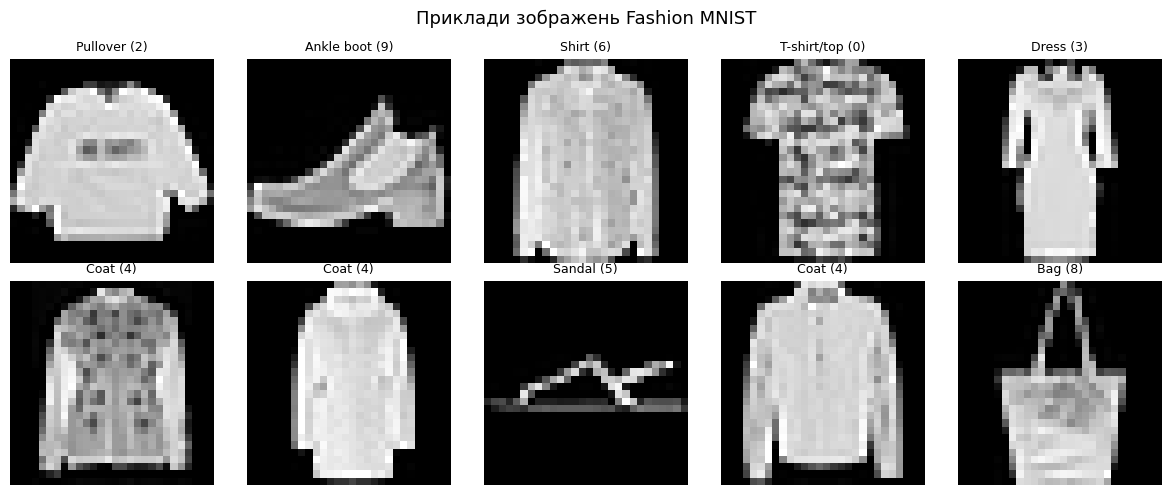

In [24]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df  = pd.read_csv('fashion-mnist_test.csv')

y_train_raw = train_df['label'].values
X_train_raw = train_df.drop('label', axis=1).values  # (60000, 784)

y_test_raw  = test_df['label'].values
X_test_raw  = test_df.drop('label', axis=1).values   # (10000, 784)

# Повертаємо пікселі у формат зображень для візуалізації
X_train_imgs = X_train_raw.reshape(-1, 28, 28)
X_test_imgs  = X_test_raw.reshape(-1, 28, 28)

print(f"Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")
print(f"Діапазон пікселів: [{X_train_raw.min()}, {X_train_raw.max()}]")

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_imgs[i], cmap='gray')
    ax.set_title(f"{CLASS_NAMES[y_train_raw[i]]} ({y_train_raw[i]})", fontsize=9)
    ax.axis('off')
plt.suptitle('Приклади зображень Fashion MNIST', fontsize=13)
plt.tight_layout()
plt.show()

> Бачимо кількість завантажених тренувального та перевірочного наборів. Дані ще не нормалізовані.

> На графіку показано 10 випадкових зображень з тренувального набору, над кожним - назва класу та його номер.

### Нормалізація 

Нормалізуємо пікселі: [0, 255] → [0.0, 1.0], аби уникнути нестабільності навчання через великі значення пікселів. 
Ділимо на максимальне значення пікселя - 255.0.

In [25]:
X_train_norm = X_train_raw.astype(np.float64) / 255.0  # (60000, 784)
X_test_norm  = X_test_raw.astype(np.float64)  / 255.0  # (10000, 784)

print(f"X_train: {X_train_norm.shape} | діапазон [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")
print(f"X_test:  {X_test_norm.shape}  | діапазон [{X_test_norm.min():.1f}, {X_test_norm.max():.1f}]")

X_train: (60000, 784) | діапазон [0.0, 1.0]
X_test:  (10000, 784)  | діапазон [0.0, 1.0]


> Дані нормалізовано.

### Розбиття тренувального набору на train/val

Датасет вже містить окремий тестовий набір, тому розбиваємо лише тренувальний. Також перемішуємо індекси для рівномірного розподілу класів за допомогою np.random.permutation.


Train: 48000 | Val: 12000 | Test: 10000


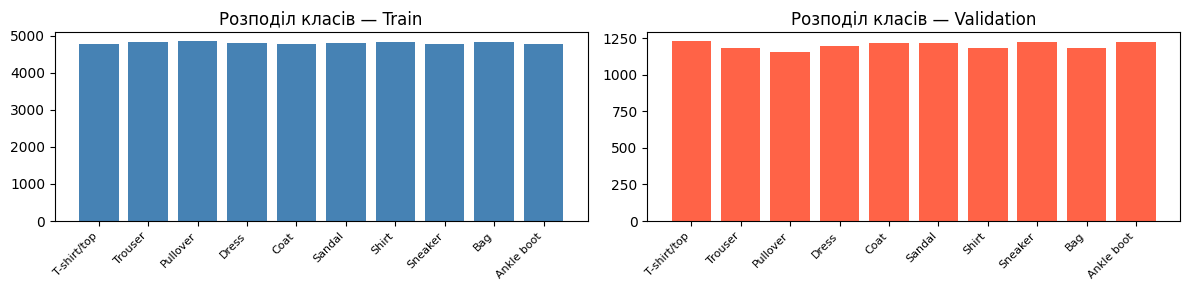

In [26]:
np.random.seed(42)

n_total   = X_train_norm.shape[0]       # 60 000
n_train   = int(n_total * 0.8)          # 48 000
indices   = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx   = indices[n_train:]

X_train = X_train_norm[train_idx]       # (48000, 784)
y_train = y_train_raw[train_idx]        # (48000,)
X_val   = X_train_norm[val_idx]         # (12000, 784)
y_val   = y_train_raw[val_idx]          # (12000,)
X_test  = X_test_norm                   # (10000, 784)
y_test  = y_test_raw                    # (10000,)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].bar(range(10), np.bincount(y_train), color='steelblue')
axes[0].set_title('Розподіл класів — Train')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
axes[1].bar(range(10), np.bincount(y_val), color='tomato')
axes[1].set_title('Розподіл класів — Validation')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

> Бачимо такий результат розбиття: тренувальний набір - 48000, валідаційна множина - 12000, тестовий - 10000. 

> Гістограми показують розподіл класів після розбиття - стовпці приблизно однакової висоти, що означає рівномірний розподіл усіх 10 класів.

### Функції активації та допоміжні функції

Всі функції активації реалізуємо вручну через numpy. Для кожної функції визначено похідну.

**Допоміжні функції:**
- softmax — активація вихідного шару, перетворює логіти у ймовірності
- cross_entropy_loss — функція втрат 
- one_hot — кодування міток для обчислення втрат

In [27]:
def relu(z):
    # **ReLU:** `f(z) = max(0, z)`
    return np.maximum(0, z)

def relu_deriv(z):
    # `f'(z) = 1` якщо `z > 0`, інакше `0`
    return (z > 0).astype(np.float64)

def tanh_act(z):
    # **Tanh:** `f(z) = tanh(z)`, діапазон `(-1, 1)`
    return np.tanh(z)

def tanh_deriv(z):
    # `f'(z) = 1 - tanh²(z)`
    return 1.0 - np.tanh(z) ** 2

def leaky_relu(z, alpha=0.01):
    # **LeakyReLU:** `f(z) = z` якщо `z > 0`, інакше `alpha*z`
    # Вирішує проблему «мертвих нейронів» ReLU
    return np.where(z > 0, z, alpha * z)

def leaky_relu_deriv(z, alpha=0.01):
    # `f'(z) = 1` якщо `z > 0`, інакше `alpha`
    return np.where(z > 0, 1.0, alpha)

def parametric_relu(z, alpha):
    # **PReLU:** як LeakyReLU, але `alpha` — гіперпараметр
    return np.where(z > 0, z, alpha * z)

def parametric_relu_deriv(z, alpha):
    return np.where(z > 0, 1.0, alpha)

def elu(z, alpha=1.0):
    # **ELU:** `f(z) = z` якщо `z > 0`, інакше `alpha*(e^z - 1)`
    # Від'ємна частина плавна → центрує активації навколо нуля
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

def elu_deriv(z, alpha=1.0):
    # `f'(z) = 1` якщо `z > 0`, інакше `ELU(z) + alpha`
    return np.where(z > 0, 1.0, elu(z, alpha) + alpha)

def softmax(z):
    # **Softmax:** перетворює логіти у ймовірності (сума = 1), лише для вихідного шару
    # Віднімаємо `max(z)` для числової стабільності
    shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z   = np.exp(shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true_onehot):
    # **Cross-entropy:** `L = -1/N * Σ( y_true * log(y_pred) )`
    # `eps=1e-12` — захист від `log(0)`
    eps = 1e-12
    return -np.sum(y_true_onehot * np.log(y_pred + eps)) / y_pred.shape[0]

def one_hot(y, num_classes=10):
    # Перетворення міток у one-hot: `3 → [0,0,0,1,0,0,0,0,0,0]`
    oh = np.zeros((y.shape[0], num_classes), dtype=np.float64)
    oh[np.arange(y.shape[0]), y] = 1.0
    return oh

### Алгоритм зворотного розповсюдження помилки (backpropagation)

Реалізуємо метод `backward()` у класі `NeuralNetwork`. Алгоритм рухається від вихідного шару до вхідного і обчислює градієнти для кожної матриці ваг та вектора зміщень.

Для вихідного шару використовується спрощена формула, яка виникає при комбінації softmax та cross-entropy:

`δZ = A_out − Y_one_hot`

Для кожного прихованого шару (рухаємось назад):

- `δW = (1/N) · Aᵀ · δZ` — градієнт ваг
- `δb = mean(δZ)` — градієнт зміщень  
- `δZ_prev = (δZ · Wᵀ) ⊙ f'(Z)` — передача помилки на попередній шар

In [28]:
class NeuralNetwork(object):

    def __init__(self, layer_sizes, hidden_activation='relu', alpha=0.01):
        self.layer_sizes       = layer_sizes
        self.hidden_activation = hidden_activation
        self.alpha             = alpha
        self.num_layers        = len(layer_sizes)
        self.weights, self.biases = [], []
        np.random.seed(42)
        for i in range(self.num_layers - 1):
            fan_in = layer_sizes[i]
            std = np.sqrt(2.0 / fan_in) if hidden_activation != 'tanh' else np.sqrt(1.0 / fan_in)
            self.weights.append(np.random.normal(0.0, std, size=(fan_in, layer_sizes[i + 1])))
            self.biases.append(np.zeros((1, layer_sizes[i + 1])))

    def _activate(self, z, is_output=False):
        if is_output:                                   return softmax(z)
        if self.hidden_activation == 'relu':            return relu(z)
        if self.hidden_activation == 'tanh':            return tanh_act(z)
        if self.hidden_activation == 'leaky_relu':      return leaky_relu(z, self.alpha)
        if self.hidden_activation == 'parametric_relu': return parametric_relu(z, self.alpha)
        if self.hidden_activation == 'elu':             return elu(z, self.alpha)

    def _activate_deriv(self, z):
        if self.hidden_activation == 'relu':            return relu_deriv(z)
        if self.hidden_activation == 'tanh':            return tanh_deriv(z)
        if self.hidden_activation == 'leaky_relu':      return leaky_relu_deriv(z, self.alpha)
        if self.hidden_activation == 'parametric_relu': return parametric_relu_deriv(z, self.alpha)
        if self.hidden_activation == 'elu':             return elu_deriv(z, self.alpha)

    def forward(self, X):
        cache = {'A': [X], 'Z': []}
        A = X
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            Z = A @ W + b
            A = self._activate(Z, is_output=(i == self.num_layers - 2))
            cache['Z'].append(Z)
            cache['A'].append(A)
        return A, cache

    # зворотне розповсюдження помилки
    def backward(self, cache, y):
        N        = y.shape[0]
        Y_onehot = one_hot(y)
        dW = [None] * (self.num_layers - 1)
        db = [None] * (self.num_layers - 1)

        # Градієнт вихідного шару: softmax + cross-entropy → спрощена похідна
        dZ = cache['A'][-1] - Y_onehot

        for i in reversed(range(self.num_layers - 1)):
            A_prev = cache['A'][i]
            dW[i]  = A_prev.T @ dZ / N
            db[i]  = np.mean(dZ, axis=0, keepdims=True)
            if i > 0:
                dZ = (dZ @ self.weights[i].T) * self._activate_deriv(cache['Z'][i - 1])

        return dW, db

    def compute_loss(self, X, y):
        y_pred, _ = self.forward(X)
        return cross_entropy_loss(y_pred, one_hot(y))

    def predict(self, X):
        y_pred, _ = self.forward(X)
        return np.argmax(y_pred, axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    def summary(self):
        print(f"Активація прихованих шарів: {self.hidden_activation}")
        total = 0
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            name   = 'Вихідний (softmax)' if i == len(self.weights) - 1 else f'Прихований {i + 1}'
            params = W.size + b.size
            total += params
            print(f"  [{name}]  W:{W.shape}  b:{b.shape}  параметрів:{params}")
        print(f"Всього параметрів: {total}")

### Функція навчання 

Функцією втрат обрано **перехресну ентропію** (cross-entropy), яка вже реалізована вище як `cross_entropy_loss`.

Навчання відбувається методом **міні-батч SGD**:
1. Дані перемішуються на початку кожної епохи
2. Для кожного батчу виконується: forward → backward → оновлення ваг
3. Оновлення ваг: `W -= lr * δW`, `b -= lr * δb`
4. Після кожної епохи збираються метрики на тренувальній і валідаційній множинах

In [29]:

def train(model, X_train, y_train, X_val, y_val, epochs=30, lr=0.01, batch_size=256, verbose=True):

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    N = X_train.shape[0]

    for epoch in range(1, epochs + 1):
        perm = np.random.permutation(N)
        X_sh, y_sh = X_train[perm], y_train[perm]

        for start in range(0, N, batch_size):
            Xb, yb   = X_sh[start:start + batch_size], y_sh[start:start + batch_size]
            _, cache = model.forward(Xb)
            dW, db   = model.backward(cache, yb)
            for i in range(model.num_layers - 1):
                model.weights[i] -= lr * dW[i]
                model.biases[i]  -= lr * db[i]

        tl = model.compute_loss(X_train, y_train)
        vl = model.compute_loss(X_val,   y_val)
        ta = model.accuracy(X_train, y_train)
        va = model.accuracy(X_val,   y_val)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)

        if verbose:
            print(f"Епоха {epoch:3d}/{epochs} | "
              f"loss: {tl:.4f}  val_loss: {vl:.4f} | "
              f"acc: {ta*100:.2f}%  val_acc: {va*100:.2f}%")

    return history

### Навчання базової мережі

Навчаємо базову мережу з одним прихованим шаром (784 → 128 → 10), активація — **ReLU**. Гіперпараметри: `lr=0.01`, `batch_size=256`, `epochs=30`.

In [30]:
base_model = NeuralNetwork(layer_sizes=[784, 128, 10], hidden_activation='relu')
base_model.summary()

print("\nНавчання базової мережі (1 прихований шар, ReLU):")
history_base = train(base_model, X_train, y_train, X_val, y_val, epochs=30, lr=0.01)

print(f"\nФінальна точність на валідації: {base_model.accuracy(X_val, y_val)*100:.2f}%")
print(f"Фінальна точність на тесті:     {base_model.accuracy(X_test, y_test)*100:.2f}%")

Активація прихованих шарів: relu
  [Прихований 1]  W:(784, 128)  b:(1, 128)  параметрів:100480
  [Вихідний (softmax)]  W:(128, 10)  b:(1, 10)  параметрів:1290
Всього параметрів: 101770

Навчання базової мережі (1 прихований шар, ReLU):
Епоха   1/30 | loss: 0.9886  val_loss: 0.9964 | acc: 68.76%  val_acc: 68.33%
Епоха   2/30 | loss: 0.8013  val_loss: 0.8089 | acc: 73.81%  val_acc: 73.35%
Епоха   3/30 | loss: 0.7210  val_loss: 0.7294 | acc: 76.70%  val_acc: 76.34%
Епоха   4/30 | loss: 0.6699  val_loss: 0.6771 | acc: 78.17%  val_acc: 77.94%
Епоха   5/30 | loss: 0.6345  val_loss: 0.6422 | acc: 79.35%  val_acc: 79.17%
Епоха   6/30 | loss: 0.6078  val_loss: 0.6168 | acc: 80.29%  val_acc: 80.23%
Епоха   7/30 | loss: 0.5871  val_loss: 0.5958 | acc: 80.76%  val_acc: 80.52%
Епоха   8/30 | loss: 0.5719  val_loss: 0.5801 | acc: 81.12%  val_acc: 80.83%
Епоха   9/30 | loss: 0.5559  val_loss: 0.5648 | acc: 81.59%  val_acc: 81.21%
Епоха  10/30 | loss: 0.5443  val_loss: 0.5536 | acc: 81.94%  val_acc: 8

Базову мережу навчено. Loss стабільно знижується протягом усіх 30 епох — з 0.99 до 0.45. Точність на валідації та тесті практично однакова (84.20% і 84.56%), що свідчить про відсутність перенавчання. Різниця між train_loss та val_loss мінімальна, модель добре узагальнює.

### Альтернативні MLP з кількома прихованими шарами

Будуємо три додаткові архітектури:
- 2 приховані шари ReLU (784 -> 256 -> 128 -> 10)
- 3 приховані шари ReLU (784 -> 256 -> 128 -> 64 -> 10)
- 2 приховані шари tanh (784 -> 256 -> 128 -> 10)

In [31]:
configs = [
    {'name': '2 hidden ReLU [256,128]',   'layers': [784, 256, 128, 10], 'act': 'relu'},
    {'name': '3 hidden ReLU [256,128,64]', 'layers': [784, 256, 128, 64, 10], 'act': 'relu'},
    {'name': '2 hidden tanh [256,128]',    'layers': [784, 256, 128, 10], 'act': 'tanh'},
]

histories = {}
models = {}

for cfg in configs:
    print(f"{' '*60}")
    print(f"Модель: {cfg['name']}")
    model = NeuralNetwork(layer_sizes=cfg['layers'], hidden_activation=cfg['act'])
    model.summary()
    hist = train(model, X_train, y_train, X_val, y_val, epochs=30, lr=0.01)
    histories[cfg['name']] = hist
    models[cfg['name']] = model
    print(f"Точність на валідації: {model.accuracy(X_val, y_val)*100:.2f}%")
    print(f"Точність на тесті:    {model.accuracy(X_test, y_test)*100:.2f}%")

                                                            
Модель: 2 hidden ReLU [256,128]
Активація прихованих шарів: relu
  [Прихований 1]  W:(784, 256)  b:(1, 256)  параметрів:200960
  [Прихований 2]  W:(256, 128)  b:(1, 128)  параметрів:32896
  [Вихідний (softmax)]  W:(128, 10)  b:(1, 10)  параметрів:1290
Всього параметрів: 235146
Епоха   1/30 | loss: 0.8722  val_loss: 0.8786 | acc: 72.66%  val_acc: 72.58%
Епоха   2/30 | loss: 0.7046  val_loss: 0.7123 | acc: 76.91%  val_acc: 76.89%
Епоха   3/30 | loss: 0.6273  val_loss: 0.6351 | acc: 79.75%  val_acc: 79.72%
Епоха   4/30 | loss: 0.5917  val_loss: 0.6016 | acc: 79.92%  val_acc: 80.02%
Епоха   5/30 | loss: 0.5563  val_loss: 0.5632 | acc: 81.07%  val_acc: 81.22%
Епоха   6/30 | loss: 0.5262  val_loss: 0.5360 | acc: 82.33%  val_acc: 81.96%
Епоха   7/30 | loss: 0.5101  val_loss: 0.5198 | acc: 82.60%  val_acc: 82.35%
Епоха   8/30 | loss: 0.5118  val_loss: 0.5191 | acc: 82.40%  val_acc: 82.29%
Епоха   9/30 | loss: 0.4850  val_loss: 0.4967

Найкращий результат показала мережа з двома прихованими шарами ReLU - на тестовому наборі перевершила базову модель на ~1.3%. Додавання третього шару погіршило якість, бо на 27-й та 30-й епохах відбулися різкі стрибки функції втрат, що свідчить про нестабільність навчання глибшої мережі при даному learning rate. Модель з 2 прихованими шарами tanh показала результат, схожий на базову ReLU, але навчалася повільніше.

### Графіки функції втрат та accuracy для всіх моделей

Порівнюємо базову модель (1 прихований шар) з альтернативними архітектурами.

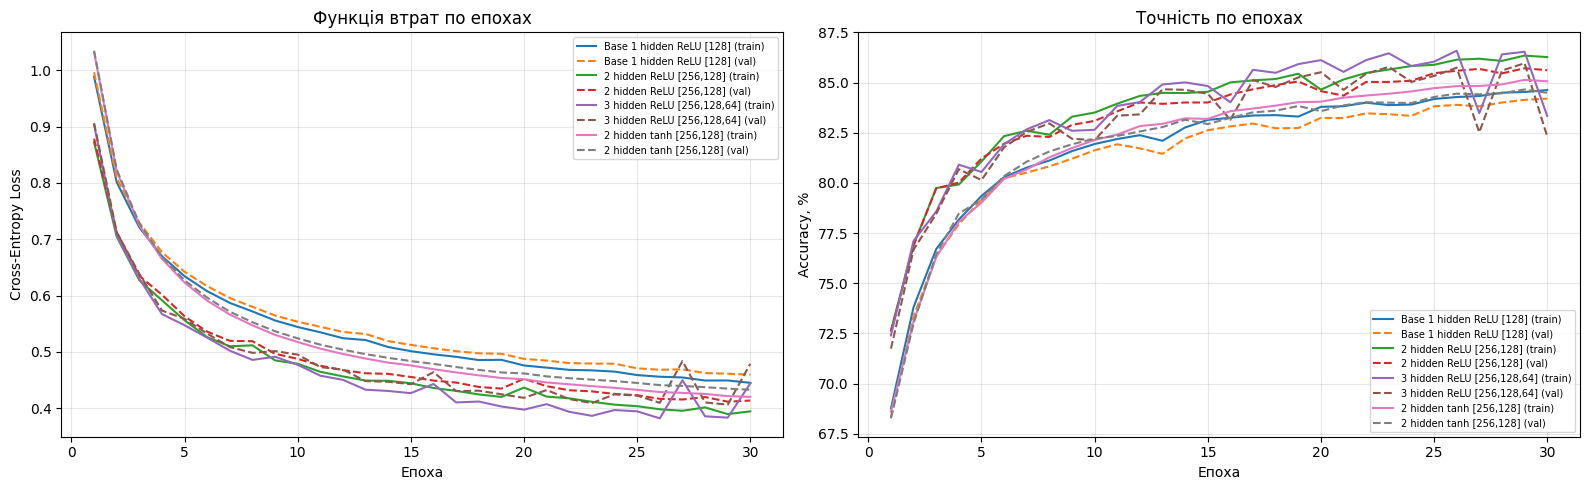

In [32]:
# Об'єднуємо базову модель з альтернативними
all_histories = {'Base 1 hidden ReLU [128]': history_base}
all_histories.update(histories)

all_models = {'Base 1 hidden ReLU [128]': base_model}
all_models.update(models)

# Зведений графік: Loss і Accuracy
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, h in all_histories.items():
    epochs_range = range(1, len(h['train_loss']) + 1)
    axes[0].plot(epochs_range, h['train_loss'], label=f'{name} (train)')
    axes[0].plot(epochs_range, h['val_loss'], '--', label=f'{name} (val)')

axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Функція втрат по епохах')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

for name, h in all_histories.items():
    epochs_range = range(1, len(h['train_acc']) + 1)
    axes[1].plot(epochs_range, [a * 100 for a in h['train_acc']], label=f'{name} (train)')
    axes[1].plot(epochs_range, [a * 100 for a in h['val_acc']], '--', label=f'{name} (val)')

axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Accuracy, %')
axes[1].set_title('Точність по епохах')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Окремі графіки для кожної моделі:

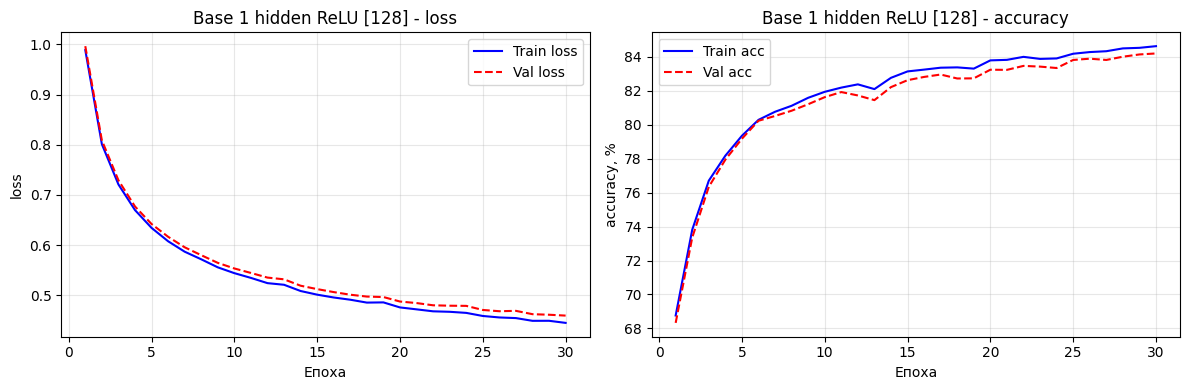

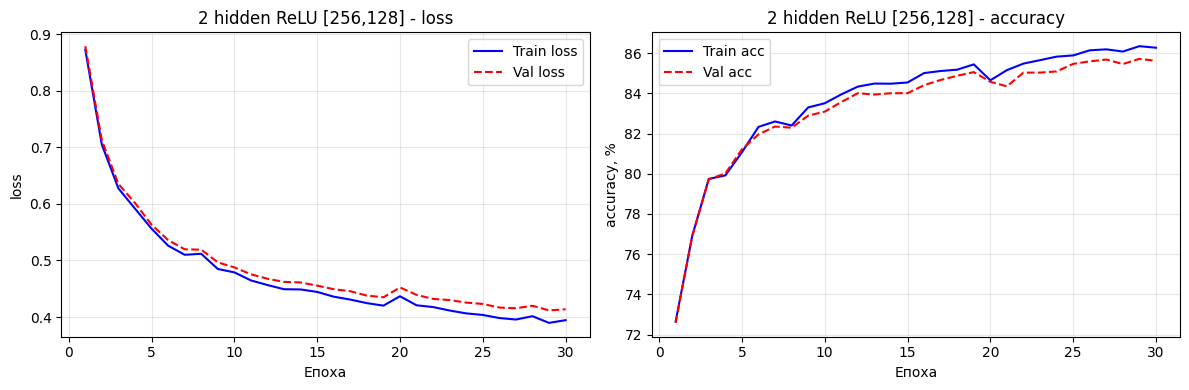

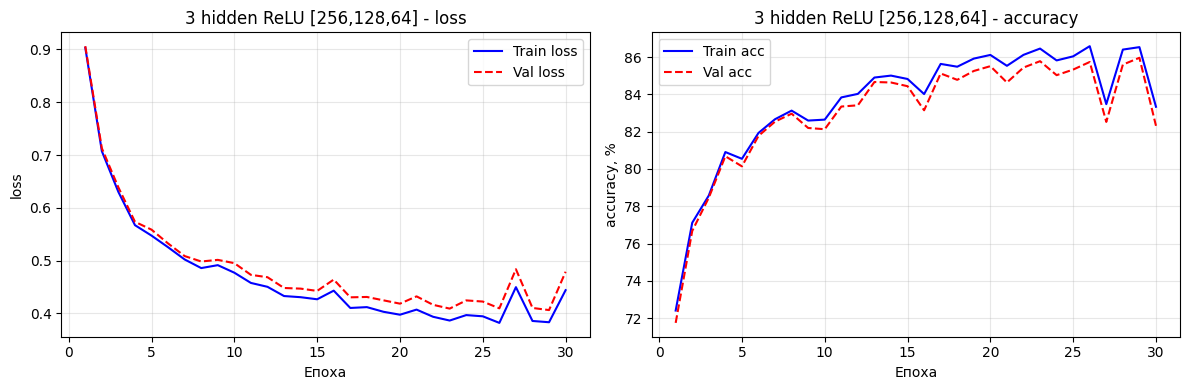

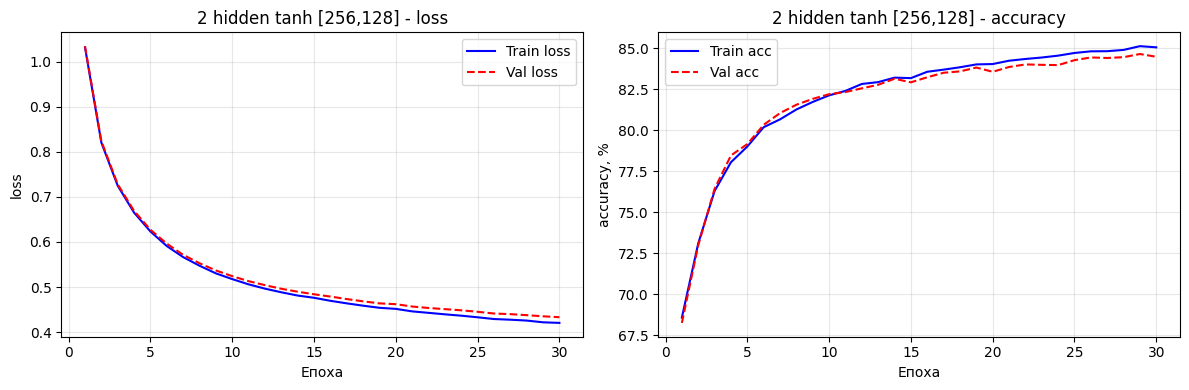

In [44]:
for name, h in all_histories.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(1, len(h['train_loss']) + 1)

    axes[0].plot(epochs_range, h['train_loss'], 'b-', label='Train loss')
    axes[0].plot(epochs_range, h['val_loss'], 'r--', label='Val loss')
    axes[0].set_xlabel('Епоха')
    axes[0].set_ylabel('loss')
    axes[0].set_title(f'{name} - loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, [a * 100 for a in h['train_acc']], 'b-', label='Train acc')
    axes[1].plot(epochs_range, [a * 100 for a in h['val_acc']], 'r--', label='Val acc')
    axes[1].set_xlabel('Епоха')
    axes[1].set_ylabel('accuracy, %')
    axes[1].set_title(f'{name} - accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Підбір learning rate

Тестуємо 5 значень швидкості навчання на архітектурі з двома прихованими шарами ReLU, бо різниця буде помітнішою, ніж з одним прихованим шаром.

In [35]:
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_histories = {}

for lr_val in learning_rates:
    print(f"--- lr = {lr_val} ---")
    model_lr = NeuralNetwork(layer_sizes=[784, 256, 128, 10], hidden_activation='relu')
    hist_lr = train(model_lr, X_train, y_train, X_val, y_val, epochs=30, lr=lr_val, verbose=False)
    lr_histories[lr_val] = hist_lr
    print(f"Фінальна val_acc: {model_lr.accuracy(X_val, y_val)*100:.2f}%")

--- lr = 0.001 ---
Фінальна val_acc: 79.67%
--- lr = 0.005 ---
Фінальна val_acc: 84.34%
--- lr = 0.01 ---
Фінальна val_acc: 85.62%
--- lr = 0.05 ---
Фінальна val_acc: 87.95%
--- lr = 0.1 ---
Фінальна val_acc: 87.51%


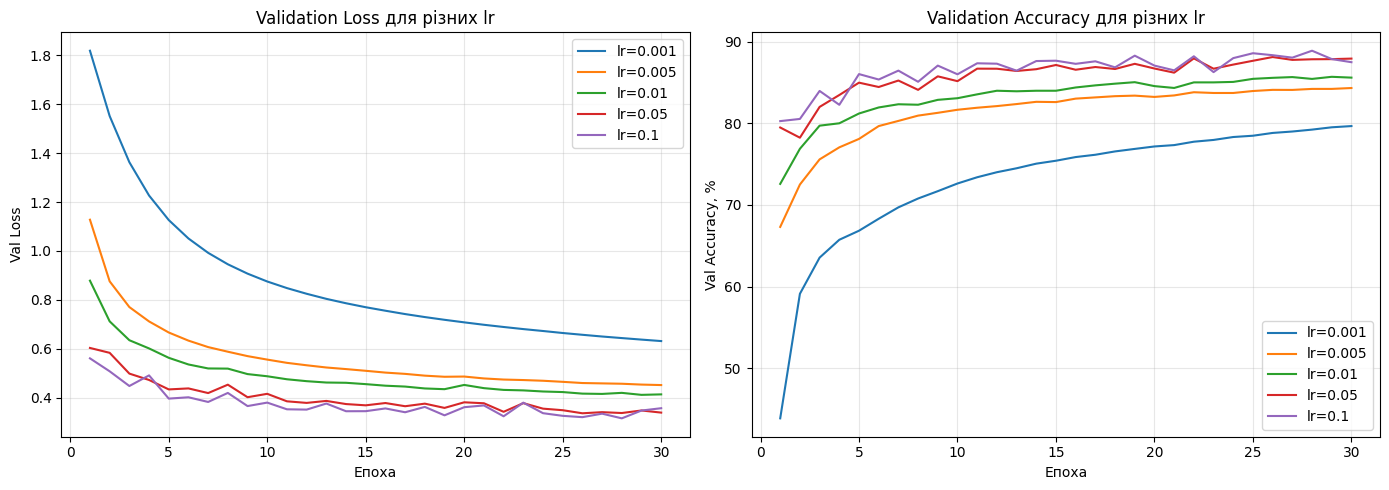

lr         Фін. val_loss    Фін. val_acc    
0.001      0.6317           79.67          %
0.005      0.4519           84.34          %
0.01       0.4138           85.62          %
0.05       0.3393           87.95          %
0.1        0.3572           87.51          %


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr_val, h in lr_histories.items():
    epochs_range = range(1, len(h['val_loss']) + 1)
    axes[0].plot(epochs_range, h['val_loss'], label=f'lr={lr_val}')
    axes[1].plot(epochs_range, [a * 100 for a in h['val_acc']], label=f'lr={lr_val}')

axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('Validation Loss для різних lr')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Val Accuracy, %')
axes[1].set_title('Validation Accuracy для різних lr')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'lr':<10} {'Фін. val_loss':<16} {'Фін. val_acc':<16}")
for lr_val, h in lr_histories.items():
    print(f"{lr_val:<10} {h['val_loss'][-1]:<16.4f} {h['val_acc'][-1]*100:<15.2f}%")

Бачимо, що при збільшенні lr від 0.001 до 0.05 val_acc стабільно зростає, однак при lr=0.1 точність дещо знижується (на ~0.4%) порівняно з lr=0.05, а val_loss зростає, тобто крок оптимізації стає завеликим і мережа перестрибує мінімум. Отже, оптимальним значенням для даної задачі є lr=0.05.

### Порівняння функцій активації

Для архітектури [784, 256, 128, 10] і оптимального значення learning rate з минулого пункту (0.05) порівнюємо функції активації ReLU, LeakyReLU, Parametric ReLU, ELU, Tanh.
Вимірюємо час навчання, час прогнозу та фінальну точність.

In [37]:
import time

activation_configs = [
    {'name': 'ReLU',             'act': 'relu',             'alpha': 0.01},
    {'name': 'LeakyReLU',        'act': 'leaky_relu',       'alpha': 0.01},
    {'name': 'Parametric ReLU',  'act': 'parametric_relu',  'alpha': 0.25},
    {'name': 'ELU',              'act': 'elu',              'alpha': 1.0},
    {'name': 'Tanh',             'act': 'tanh',             'alpha': 0.01},
]

best_lr = 0.05
act_results = {}

for cfg in activation_configs:
    print(f"Активація: {cfg['name']}")

    model_act = NeuralNetwork(
        layer_sizes=[784, 256, 128, 10],
        hidden_activation=cfg['act'],
        alpha=cfg['alpha']
    )

    t_start = time.time()
    hist_act = train(model_act, X_train, y_train, X_val, y_val, epochs=30, lr=best_lr, verbose=False)
    train_time = time.time() - t_start

    t_start = time.time()
    for _ in range(10):
        _ = model_act.predict(X_test)
    predict_time = (time.time() - t_start) / 10

    val_acc = model_act.accuracy(X_val, y_val)
    test_acc = model_act.accuracy(X_test, y_test)

    act_results[cfg['name']] = {
        'history': hist_act, 'model': model_act,
        'train_time': train_time, 'predict_time': predict_time,
        'val_acc': val_acc, 'test_acc': test_acc
    }

    print(f"Час навчання:  {train_time:.2f} с")
    print(f"Час прогнозу:  {predict_time*1000:.2f} мс")
    print(f"Val accuracy:  {val_acc*100:.2f}%")
    print(f"Test accuracy: {test_acc*100:.2f}%")

Активація: ReLU
Час навчання:  98.98 с
Час прогнозу:  76.62 мс
Val accuracy:  87.95%
Test accuracy: 87.66%
Активація: LeakyReLU
Час навчання:  104.45 с
Час прогнозу:  88.00 мс
Val accuracy:  87.71%
Test accuracy: 87.57%
Активація: Parametric ReLU
Час навчання:  113.42 с
Час прогнозу:  84.71 мс
Val accuracy:  87.09%
Test accuracy: 87.13%
Активація: ELU
Час навчання:  121.71 с
Час прогнозу:  109.26 мс
Val accuracy:  87.08%
Test accuracy: 87.28%
Активація: Tanh
Час навчання:  118.87 с
Час прогнозу:  119.99 мс
Val accuracy:  86.75%
Test accuracy: 86.91%


Активація            Час навч., с   Час прогн., мс   Val acc, %   Test acc, % 
ReLU                 98.98          76.62            87.95        87.66       
LeakyReLU            104.45         88.00            87.71        87.57       
Parametric ReLU      113.42         84.71            87.09        87.13       
ELU                  121.71         109.26           87.08        87.28       
Tanh                 118.87         119.99           86.75        86.91       


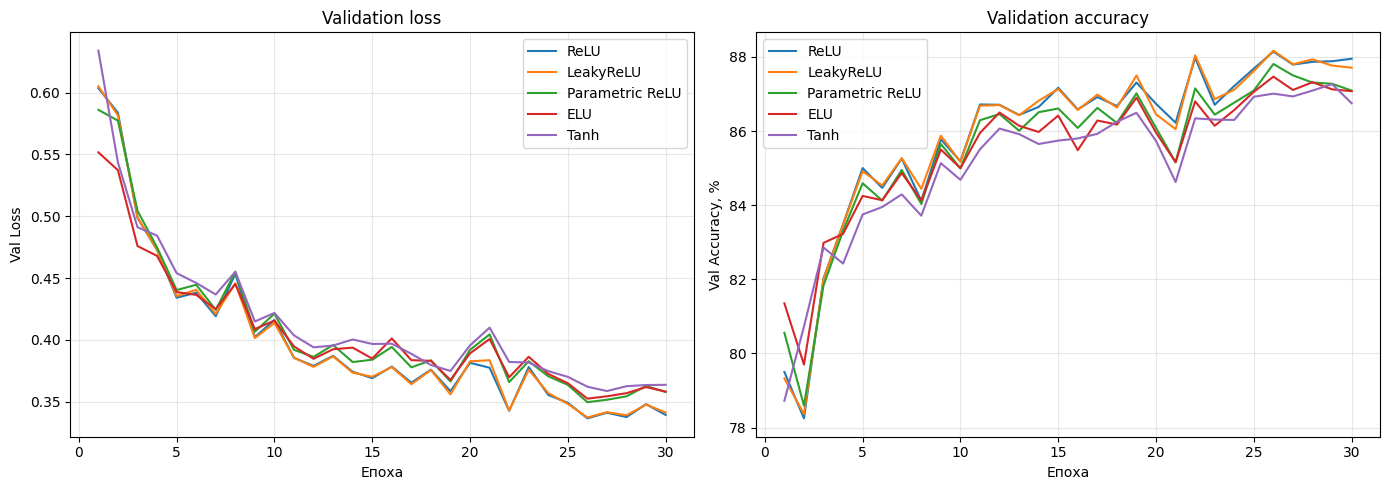

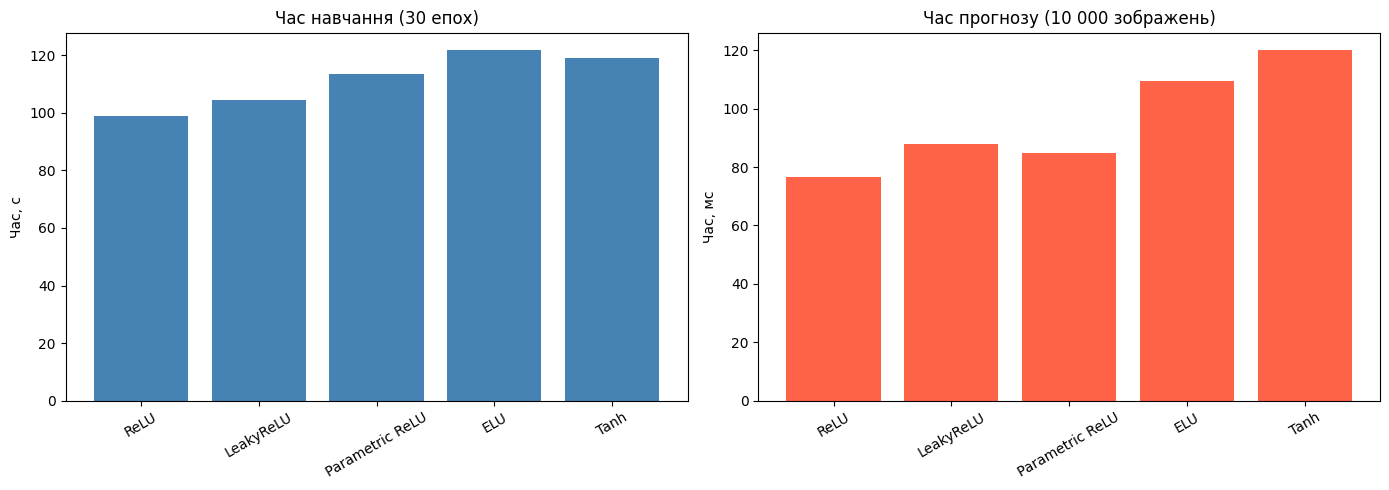

In [39]:
# зведена таблиця
print(f"{'Активація':<20} {'Час навч., с':<14} {'Час прогн., мс':<16} {'Val acc, %':<12} {'Test acc, %':<12}")
for name, res in act_results.items():
    print(f"{name:<20} {res['train_time']:<14.2f} {res['predict_time']*1000:<16.2f} "
          f"{res['val_acc']*100:<12.2f} {res['test_acc']*100:<12.2f}")

# графіки loss і accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in act_results.items():
    h = res['history']
    epochs_range = range(1, len(h['val_loss']) + 1)
    axes[0].plot(epochs_range, h['val_loss'], label=name)
    axes[1].plot(epochs_range, [a * 100 for a in h['val_acc']], label=name)

axes[0].set_xlabel('Епоха'); axes[0].set_ylabel('Val Loss')
axes[0].set_title('Validation loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Епоха'); axes[1].set_ylabel('Val Accuracy, %')
axes[1].set_title('Validation accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# діаграми часу
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(act_results.keys())
axes[0].bar(names, [act_results[n]['train_time'] for n in names], color='steelblue')
axes[0].set_ylabel('Час, с'); axes[0].set_title('Час навчання (30 епох)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(names, [act_results[n]['predict_time']*1000 for n in names], color='tomato')
axes[1].set_ylabel('Час, мс'); axes[1].set_title('Час прогнозу (10 000 зображень)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

Усі функції активації показали близьку точність, різниця між найкращою (ReLU) і найгіршою (tanh) складає ~1.2%. Тобто на даному наборі даних і даній архітектурі вибір активації не є критичним фактором.    
ReLU виявилась найшвидшю, оскільки обчислюється лише порівняння з нулем. ELU найповільніша, на ~23% довше, бо використовує операцію exp() для від'ємних значень. Tanh також повільна через обчислення гіперболічного тангенса. За часом прогнозу також ReLU найшвидша, а Tanh найповільніша. 

### Зображення, невірно класифіковані моделлю

Відобразимо приклади помилок базової моделі та найкращої альтернативної.

Всього невірно класифікованих (базова модель): 1544 з 10000 (15.44%)


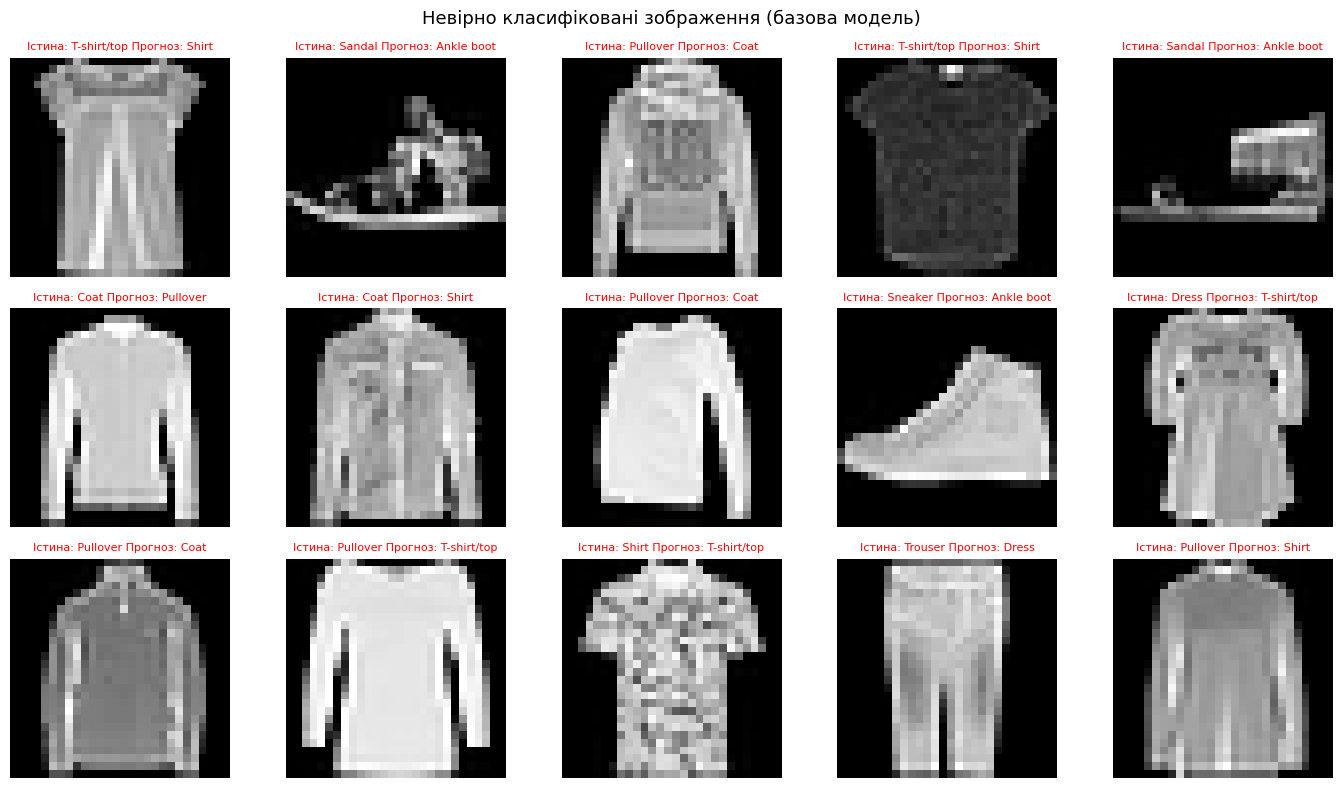

In [40]:
preds = base_model.predict(X_test)
wrong_idx = np.where(preds != y_test)[0]

print(f"Всього невірно класифікованих (базова модель): {len(wrong_idx)} з {len(y_test)} "
      f"({len(wrong_idx)/len(y_test)*100:.2f}%)")

np.random.seed(123)
sample_idx = np.random.choice(wrong_idx, size=min(15, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    if i < len(sample_idx):
        idx = sample_idx[i]
        img = X_test[idx].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        true_label = CLASS_NAMES[y_test[idx]]
        pred_label = CLASS_NAMES[preds[idx]]
        ax.set_title(f"Істина: {true_label} Прогноз: {pred_label}", fontsize=8, color='red')
    ax.axis('off')
plt.suptitle('Невірно класифіковані зображення (базова модель)', fontsize=13)
plt.tight_layout()
plt.show()

Модель: 2 hidden ReLU [256,128]
Невірно класифікованих: 1411 з 10000 (14.11%)


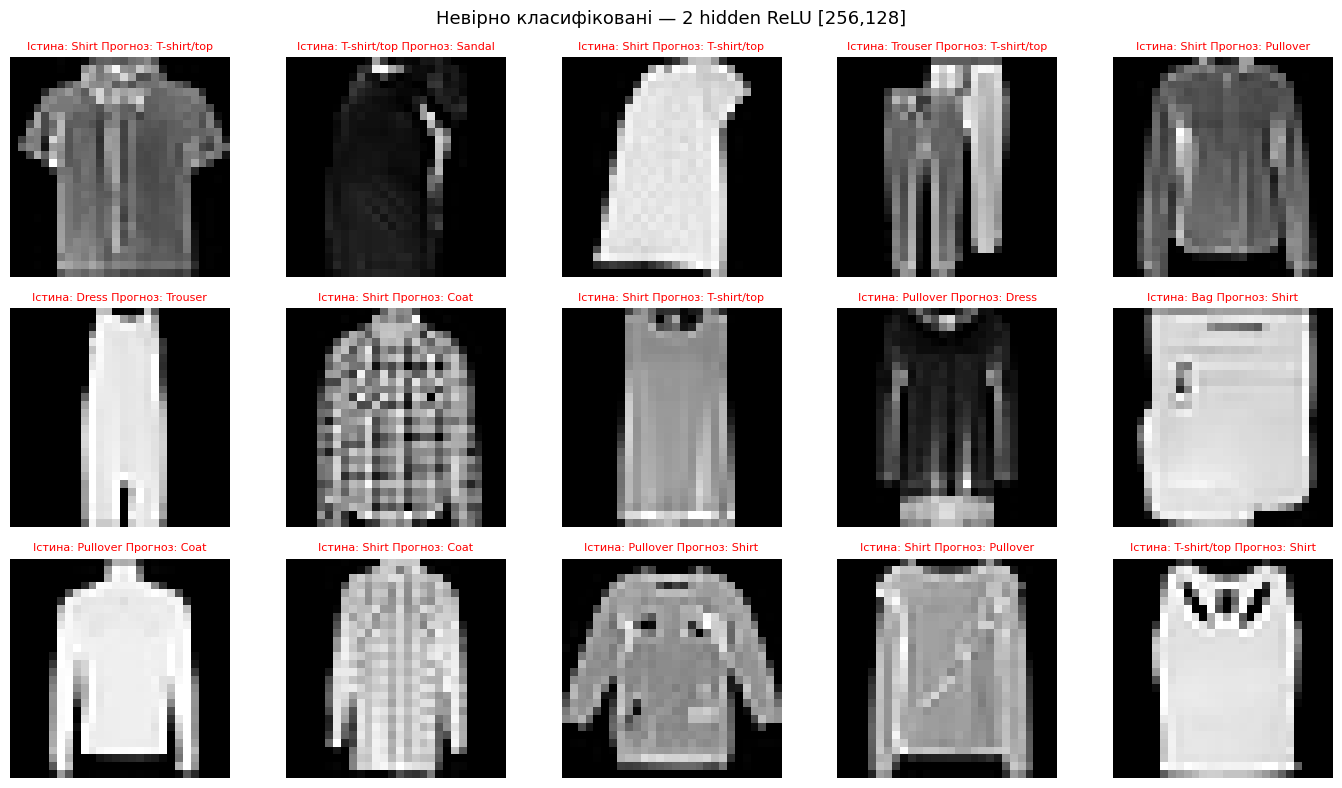

In [43]:
# Найкраща альтернативна модель
best_alt_name = max(models, key=lambda n: models[n].accuracy(X_val, y_val))
best_alt_model = models[best_alt_name]
preds_alt = best_alt_model.predict(X_test)
wrong_idx_alt = np.where(preds_alt != y_test)[0]

print(f"Модель: {best_alt_name}")
print(f"Невірно класифікованих: {len(wrong_idx_alt)} з {len(y_test)} "
      f"({len(wrong_idx_alt)/len(y_test)*100:.2f}%)")

sample_idx_alt = np.random.choice(wrong_idx_alt, size=min(15, len(wrong_idx_alt)), replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    if i < len(sample_idx_alt):
        idx = sample_idx_alt[i]
        img = X_test[idx].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        true_label = CLASS_NAMES[y_test[idx]]
        pred_label = CLASS_NAMES[preds_alt[idx]]
        ax.set_title(f"Істина: {true_label} Прогноз: {pred_label}",
                     fontsize=8, color='red')
    ax.axis('off')
plt.suptitle(f'Невірно класифіковані — {best_alt_name}', fontsize=13)
plt.tight_layout()
plt.show()

Здебільшого помилки виникли між візуально схожими класами Shirt і T-shirt/top, Pullover і Coat, Sneaker і Ankle boot.

## Висновки 
>У ході лабораторної роботи було реалізовано побудову та навчання нейронної мережі прямого розповсюдження для задачі класифікації зображень на датасеті Fashion MNIST. Було реалізовано власний клас нейронної мережі з підтримкою довільної кількості шарів, п'ять функцій активації прихованих шарів, softmax на вихідному шарі, перехресну ентропію як функцію втрат, алгоритм зворотного розповсюдження помилки та цикл навчання з mini-batch стохастичним градієнтним спуском. .    
>
>Дослідження впливу глибини мережі показало, що додавання другого прихованого шару підвищує точність класифікації з 84.56% до 85.89% на тестовій множині, оскільки додатковий шар дозволяє мережі формувати складнішу ієрархію ознак. Водночас подальше збільшення глибини до трьох прихованих шарів погіршило результат через нестабільність навчання.   
Підбір швидкості навчання підтвердив, що learning rate є одним із ключових гіперпараметрів. Занадто мале значення (0.001) призводить до недонавчання - мережа не встигає наблизитися до оптимуму за 30 епох і досягає лише ~79.7% точності. Збільшення lr до 0.05 дає найкращий результат 87.95%, проте подальше зростання до 0.1 вже дещо погіршує якість через надмірний крок оптимізації, що спричиняє перестрибування мінімуму функції втрат.
>
>Порівняння функцій активації на однаковій архітектурі з двома прихованими шарами показало, що її вибір незначно впливає на фінальну точність - найкращою виявилась ReLU з 87.95%, найгіршою tanh з 86.75%. Щодо обчислювальної ефективності, ReLU виявилася найшвидшою як при навчанні, так і при прогнозі, тоді як ELU та tanh потребували на більше часу через обчислювально складніші операції exp() та tanh(). За сукупністю швидкості та якості ReLU є оптимальним вибором для даної задачі.
>
>За аналізом помилок класифікації, мережа найчастіше плутає категорії одягу зі схожими силуетами на такому розмірі зображень, зокрема Shirt і T-shirt/top, Pullover і Coat, Sneaker і Ankle boot.   